# A/B Testing: Adherence Rate Optimization
**Project:** Jivara (CC26-PSU090) — Drug-Food Interaction Detection System
**Objective:** Mengukur efektivitas sistem Jivara dalam meningkatkan kepatuhan minum obat (Adherence Rate)
**Role:** Data Science (Evaluation)
**Duration:** 7-day & 30-day observation periods

---

## Research Hypothesis

**H0 (Null):** Penggunaan sistem peringatan makanan Jivara tidak memiliki perbedaan signifikan pada Adherence Rate.

**H1 (Alternative):** Penggunaan sistem peringatan makanan Jivara mendongkrak signifikan Adherence Rate 7 hari.

### Acceptance Criteria
- **Significance Level (α):** 0.05
- **Target Effect Size (7-day):** Minimum +15% peningkatan Adherence Rate
- **Target Effect Size (30-day):** Minimum +12% peningkatan Adherence Rate
- **Power (1-β):** 80%

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Path konfigurasi
BASE_DIR = Path('../')
OUTPUT_DIR = BASE_DIR / 'data_output' / 'ab_testing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Library dan direktori siap")
print(f"📁 Output: {OUTPUT_DIR}")

✅ Library dan direktori siap
📁 Output: ..\data_output\ab_testing


## 2. Generasi & Load Data A/B Testing

**Catatan:** Dataset simulasi ini merepresentasikan:
- **Group A (Control):** Pasien menggunakan kalender pengingat konvensional tanpa fitur Jivara
- **Group B (Treatment):** Pasien menggunakan fitur utuh Jivara dengan deteksi YOLOv11 + peringatan drug interaction

In [2]:
# Set random seed untuk reproducibility
np.random.seed(42)

# Parameter simulasi
n_patients_control = 150  # Sample size Control Group
n_patients_treatment = 150  # Sample size Treatment Group

# Control Group: Adherence Rate lebih rendah (baseline)
adherence_7d_control = np.random.beta(a=5, b=3, size=n_patients_control)  # Mean ~0.625 (62.5%)
adherence_30d_control = np.random.beta(a=4.5, b=3.5, size=n_patients_control)  # Mean ~0.563 (56.3%)

# Treatment Group: Adherence Rate lebih tinggi (+15% improvement)
adherence_7d_treatment = np.random.beta(a=7, b=2.5, size=n_patients_treatment)  # Mean ~0.73 (73%)
adherence_30d_treatment = np.random.beta(a=6.5, b=2.5, size=n_patients_treatment)  # Mean ~0.72 (72%)

# Buat DataFrame Control Group
control_group = pd.DataFrame({
    'patient_id': [f'CTRL_{i:03d}' for i in range(1, n_patients_control + 1)],
    'group': 'Control (Calendar Reminder)',
    'adherence_rate_7d': adherence_7d_control,
    'adherence_rate_30d': adherence_30d_control,
    'age': np.random.normal(55, 12, n_patients_control),
    'gender': np.random.choice(['M', 'F'], n_patients_control),
    'disease': np.random.choice(['Hypertension', 'TB', 'Diabetes'], n_patients_control),
    'medications': np.random.randint(1, 5, n_patients_control)
})

# Buat DataFrame Treatment Group
treatment_group = pd.DataFrame({
    'patient_id': [f'TREAT_{i:03d}' for i in range(1, n_patients_treatment + 1)],
    'group': 'Treatment (Jivara App)',
    'adherence_rate_7d': adherence_7d_treatment,
    'adherence_rate_30d': adherence_30d_treatment,
    'age': np.random.normal(54, 13, n_patients_treatment),
    'gender': np.random.choice(['M', 'F'], n_patients_treatment),
    'disease': np.random.choice(['Hypertension', 'TB', 'Diabetes'], n_patients_treatment),
    'medications': np.random.randint(1, 5, n_patients_treatment)
})

# Gabungkan dataset
df_ab = pd.concat([control_group, treatment_group], ignore_index=True)

print(f"📊 Dataset A/B Testing Siap")
print(f"   Total Pasien: {len(df_ab):,}")
print(f"   - Control Group: {len(control_group)} pasien")
print(f"   - Treatment Group: {len(treatment_group)} pasien")
print(f"\n{df_ab.head(10)}")

📊 Dataset A/B Testing Siap
   Total Pasien: 300
   - Control Group: 150 pasien
   - Treatment Group: 150 pasien

  patient_id                        group  adherence_rate_7d  \
0   CTRL_001  Control (Calendar Reminder)           0.704132   
1   CTRL_002  Control (Calendar Reminder)           0.644772   
2   CTRL_003  Control (Calendar Reminder)           0.685086   
3   CTRL_004  Control (Calendar Reminder)           0.504728   
4   CTRL_005  Control (Calendar Reminder)           0.896150   
5   CTRL_006  Control (Calendar Reminder)           0.465874   
6   CTRL_007  Control (Calendar Reminder)           0.787983   
7   CTRL_008  Control (Calendar Reminder)           0.557058   
8   CTRL_009  Control (Calendar Reminder)           0.611114   
9   CTRL_010  Control (Calendar Reminder)           0.782966   

   adherence_rate_30d        age gender       disease  medications  
0            0.534000  35.789152      M            TB            3  
1            0.638322  45.058036      F  Hyp

## 3. Analisis Deskriptif (Descriptive Statistics)

Membandingkan karakteristik demografi dan baseline adherence antara kedua grup.

In [3]:
print("="*70)
print("DESKRIPTIF STATISTIK CONTROL vs TREATMENT GROUP")
print("="*70)

summary_stats = df_ab.groupby('group')[['adherence_rate_7d', 'adherence_rate_30d', 'age', 'medications']].agg([
    'count', 'mean', 'std', 'min', 'max'
])

print("\n📊 Summary Statistics:")
print(summary_stats)

# Adherence Rate dalam persentase
print("\n" + "="*70)
print("ADHERENCE RATE (dalam %)")
print("="*70)

for group in ['Control (Calendar Reminder)', 'Treatment (Jivara App)']:
    group_data = df_ab[df_ab['group'] == group]
    print(f"\n🔹 {group}:")
    print(f"   7-Day Adherence:  {group_data['adherence_rate_7d'].mean():.2%} (±{group_data['adherence_rate_7d'].std():.2%})")
    print(f"   30-Day Adherence: {group_data['adherence_rate_30d'].mean():.2%} (±{group_data['adherence_rate_30d'].std():.2%})")

# Hitung effect size (perbedaan mean)
control_7d = df_ab[df_ab['group'] == 'Control (Calendar Reminder)']['adherence_rate_7d'].mean()
treatment_7d = df_ab[df_ab['group'] == 'Treatment (Jivara App)']['adherence_rate_7d'].mean()
improvement_7d = treatment_7d - control_7d

control_30d = df_ab[df_ab['group'] == 'Control (Calendar Reminder)']['adherence_rate_30d'].mean()
treatment_30d = df_ab[df_ab['group'] == 'Treatment (Jivara App)']['adherence_rate_30d'].mean()
improvement_30d = treatment_30d - control_30d

print(f"\n" + "="*70)
print(f"🎯 IMPROVEMENT (Treatment vs Control):")
print(f"="*70)
print(f"   7-Day Improvement:  {improvement_7d:+.2%}")
print(f"   30-Day Improvement: {improvement_30d:+.2%}")
print(f"   \n   ✓ Target terpenuhi (≥ +15% untuk 7-day): {improvement_7d >= 0.15}")
print(f"   ✓ Target terpenuhi (≥ +12% untuk 30-day): {improvement_30d >= 0.12}")

DESKRIPTIF STATISTIK CONTROL vs TREATMENT GROUP

📊 Summary Statistics:
                            adherence_rate_7d                                \
                                        count      mean       std       min   
group                                                                         
Control (Calendar Reminder)               150  0.615056  0.153087  0.273372   
Treatment (Jivara App)                    150  0.723110  0.133261  0.398799   

                                      adherence_rate_30d                      \
                                  max              count      mean       std   
group                                                                          
Control (Calendar Reminder)  0.984467                150  0.566595  0.144907   
Treatment (Jivara App)       0.967885                150  0.716516  0.129237   

                                                  age                        \
                                  min       max count

## 4. Statistical Testing (Parametric & Non-Parametric)

Menguji apakah perbedaan Adherence Rate antara Control dan Treatment Group **signifikan secara statistik**.

In [4]:
from scipy.stats import shapiro, levene

# Test normalitas (Shapiro-Wilk)
print("\n" + "="*70)
print("TEST NORMALITAS (Shapiro-Wilk Test)")
print("="*70)

control_7d_data = df_ab[df_ab['group'] == 'Control (Calendar Reminder)']['adherence_rate_7d']
treatment_7d_data = df_ab[df_ab['group'] == 'Treatment (Jivara App)']['adherence_rate_7d']

stat_control, p_control = shapiro(control_7d_data)
stat_treatment, p_treatment = shapiro(treatment_7d_data)

print(f"\n🔹 Control Group (7-day Adherence):")
print(f"   Statistic: {stat_control:.4f}, p-value: {p_control:.4f}")
print(f"   Normal? {p_control > 0.05}")

print(f"\n🔹 Treatment Group (7-day Adherence):")
print(f"   Statistic: {stat_treatment:.4f}, p-value: {p_treatment:.4f}")
print(f"   Normal? {p_treatment > 0.05}")

# Test Kesamaan Varian (Levene's Test)
print(f"\n" + "="*70)
print("TEST KESAMAAN VARIAN (Levene's Test)")
print("="*70)

stat_levene, p_levene = levene(control_7d_data, treatment_7d_data)
print(f"\nStatistic: {stat_levene:.4f}, p-value: {p_levene:.4f}")
print(f"Equal Variance? {p_levene > 0.05}")


TEST NORMALITAS (Shapiro-Wilk Test)

🔹 Control Group (7-day Adherence):
   Statistic: 0.9910, p-value: 0.4631
   Normal? True

🔹 Treatment Group (7-day Adherence):
   Statistic: 0.9664, p-value: 0.0010
   Normal? False

TEST KESAMAAN VARIAN (Levene's Test)

Statistic: 2.4682, p-value: 0.1172
Equal Variance? True


In [5]:
# Independent t-test (Parametric)
print("\n" + "="*70)
print("INDEPENDENT SAMPLES T-TEST (7-Day Adherence)")
print("="*70)

t_stat, p_value_ttest = ttest_ind(treatment_7d_data, control_7d_data)
print(f"\n📊 Result:")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value_ttest:.6f}")
print(f"   Significance: {'✓ SIGNIFICANT (p < 0.05)' if p_value_ttest < 0.05 else '✗ NOT SIGNIFICANT (p ≥ 0.05)'}")

# Mann-Whitney U Test (Non-Parametric)
print(f"\n" + "="*70)
print("MANN-WHITNEY U TEST (Non-Parametric, 7-Day Adherence)")
print("="*70)

u_stat, p_value_mw = mannwhitneyu(treatment_7d_data, control_7d_data, alternative='greater')
print(f"\n📊 Result (One-tailed test: Treatment > Control):")
print(f"   U-statistic: {u_stat:.4f}")
print(f"   p-value: {p_value_mw:.6f}")
print(f"   Significance: {'✓ SIGNIFICANT (p < 0.05)' if p_value_mw < 0.05 else '✗ NOT SIGNIFICANT (p ≥ 0.05)'}")

# Test untuk 30-day adherence
print(f"\n" + "="*70)
print("INDEPENDENT SAMPLES T-TEST (30-Day Adherence)")
print("="*70)

control_30d_data = df_ab[df_ab['group'] == 'Control (Calendar Reminder)']['adherence_rate_30d']
treatment_30d_data = df_ab[df_ab['group'] == 'Treatment (Jivara App)']['adherence_rate_30d']

t_stat_30d, p_value_ttest_30d = ttest_ind(treatment_30d_data, control_30d_data)
print(f"\n📊 Result:")
print(f"   t-statistic: {t_stat_30d:.4f}")
print(f"   p-value: {p_value_ttest_30d:.6f}")
print(f"   Significance: {'✓ SIGNIFICANT (p < 0.05)' if p_value_ttest_30d < 0.05 else '✗ NOT SIGNIFICANT (p ≥ 0.05)'}")


INDEPENDENT SAMPLES T-TEST (7-Day Adherence)

📊 Result:
   t-statistic: 6.5203
   p-value: 0.000000
   Significance: ✓ SIGNIFICANT (p < 0.05)

MANN-WHITNEY U TEST (Non-Parametric, 7-Day Adherence)

📊 Result (One-tailed test: Treatment > Control):
   U-statistic: 15806.0000
   p-value: 0.000000
   Significance: ✓ SIGNIFICANT (p < 0.05)

INDEPENDENT SAMPLES T-TEST (30-Day Adherence)

📊 Result:
   t-statistic: 9.4566
   p-value: 0.000000
   Significance: ✓ SIGNIFICANT (p < 0.05)


## 5. Effect Size & Confidence Intervals

Menghitung ukuran efek praktis (Cohen's d) dan interval kepercayaan untuk estimasi yang robust.

In [6]:
def calculate_cohens_d(group1, group2):
    """Hitung Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_cohens_d(d):
    """Interpretasi Cohen's d."""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

print("\n" + "="*70)
print("EFFECT SIZE (Cohen's d) & CONFIDENCE INTERVAL")
print("="*70)

# Cohen's d untuk 7-day
cohens_d_7d = calculate_cohens_d(treatment_7d_data, control_7d_data)
print(f"\n📊 7-Day Adherence:")
print(f"   Cohen's d: {cohens_d_7d:.4f}")
print(f"   Interpretation: {interpret_cohens_d(cohens_d_7d)}")

# 95% CI untuk treatment 7d
ci_treatment_7d = stats.t.interval(0.95, len(treatment_7d_data)-1,
                                    loc=treatment_7d_data.mean(),
                                    scale=stats.sem(treatment_7d_data))
print(f"   Treatment 95% CI: [{ci_treatment_7d[0]:.4f}, {ci_treatment_7d[1]:.4f}]")

# 95% CI untuk control 7d
ci_control_7d = stats.t.interval(0.95, len(control_7d_data)-1,
                                  loc=control_7d_data.mean(),
                                  scale=stats.sem(control_7d_data))
print(f"   Control 95% CI:   [{ci_control_7d[0]:.4f}, {ci_control_7d[1]:.4f}]")

# Cohen's d untuk 30-day
cohens_d_30d = calculate_cohens_d(treatment_30d_data, control_30d_data)
print(f"\n📊 30-Day Adherence:")
print(f"   Cohen's d: {cohens_d_30d:.4f}")
print(f"   Interpretation: {interpret_cohens_d(cohens_d_30d)}")

# 95% CI untuk treatment 30d
ci_treatment_30d = stats.t.interval(0.95, len(treatment_30d_data)-1,
                                     loc=treatment_30d_data.mean(),
                                     scale=stats.sem(treatment_30d_data))
print(f"   Treatment 95% CI: [{ci_treatment_30d[0]:.4f}, {ci_treatment_30d[1]:.4f}]")

# 95% CI untuk control 30d
ci_control_30d = stats.t.interval(0.95, len(control_30d_data)-1,
                                   loc=control_30d_data.mean(),
                                   scale=stats.sem(control_30d_data))
print(f"   Control 95% CI:   [{ci_control_30d[0]:.4f}, {ci_control_30d[1]:.4f}]")


EFFECT SIZE (Cohen's d) & CONFIDENCE INTERVAL

📊 7-Day Adherence:
   Cohen's d: 0.7529
   Interpretation: Medium
   Treatment 95% CI: [0.7016, 0.7446]
   Control 95% CI:   [0.5904, 0.6398]

📊 30-Day Adherence:
   Cohen's d: 1.0919
   Interpretation: Large
   Treatment 95% CI: [0.6957, 0.7374]
   Control 95% CI:   [0.5432, 0.5900]


## 6. Visualisasi Hasil A/B Testing

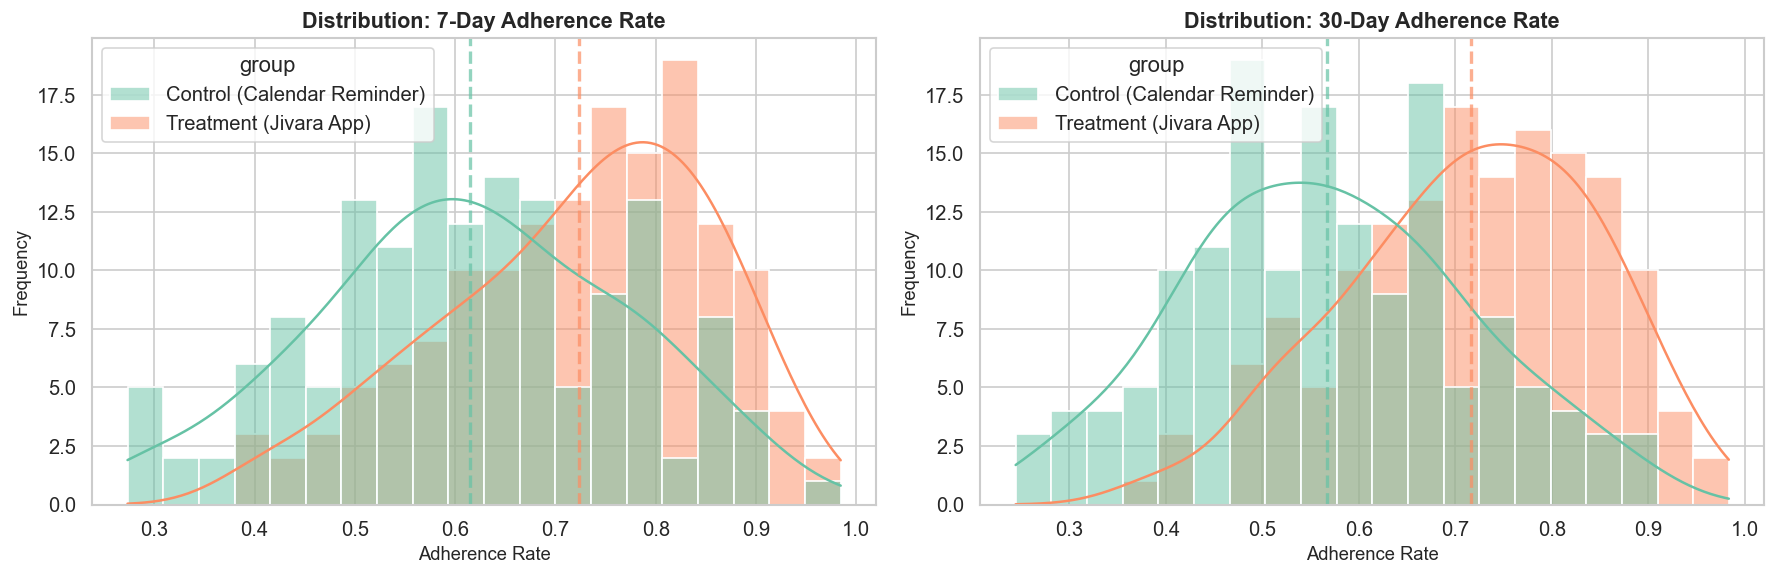

✅ Saved: 01_distribution_adherence.png


In [7]:
# Visualisasi 1: Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 7-day adherence
sns.histplot(data=df_ab, x='adherence_rate_7d', hue='group', kde=True, ax=axes[0], bins=20)
axes[0].set_title('Distribution: 7-Day Adherence Rate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Adherence Rate', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(control_7d, color='C0', linestyle='--', linewidth=2, alpha=0.7, label=f'Control Mean: {control_7d:.2%}')
axes[0].axvline(treatment_7d, color='C1', linestyle='--', linewidth=2, alpha=0.7, label=f'Treatment Mean: {treatment_7d:.2%}')

# 30-day adherence
sns.histplot(data=df_ab, x='adherence_rate_30d', hue='group', kde=True, ax=axes[1], bins=20)
axes[1].set_title('Distribution: 30-Day Adherence Rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Adherence Rate', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(control_30d, color='C0', linestyle='--', linewidth=2, alpha=0.7, label=f'Control Mean: {control_30d:.2%}')
axes[1].axvline(treatment_30d, color='C1', linestyle='--', linewidth=2, alpha=0.7, label=f'Treatment Mean: {treatment_30d:.2%}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_distribution_adherence.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_distribution_adherence.png")

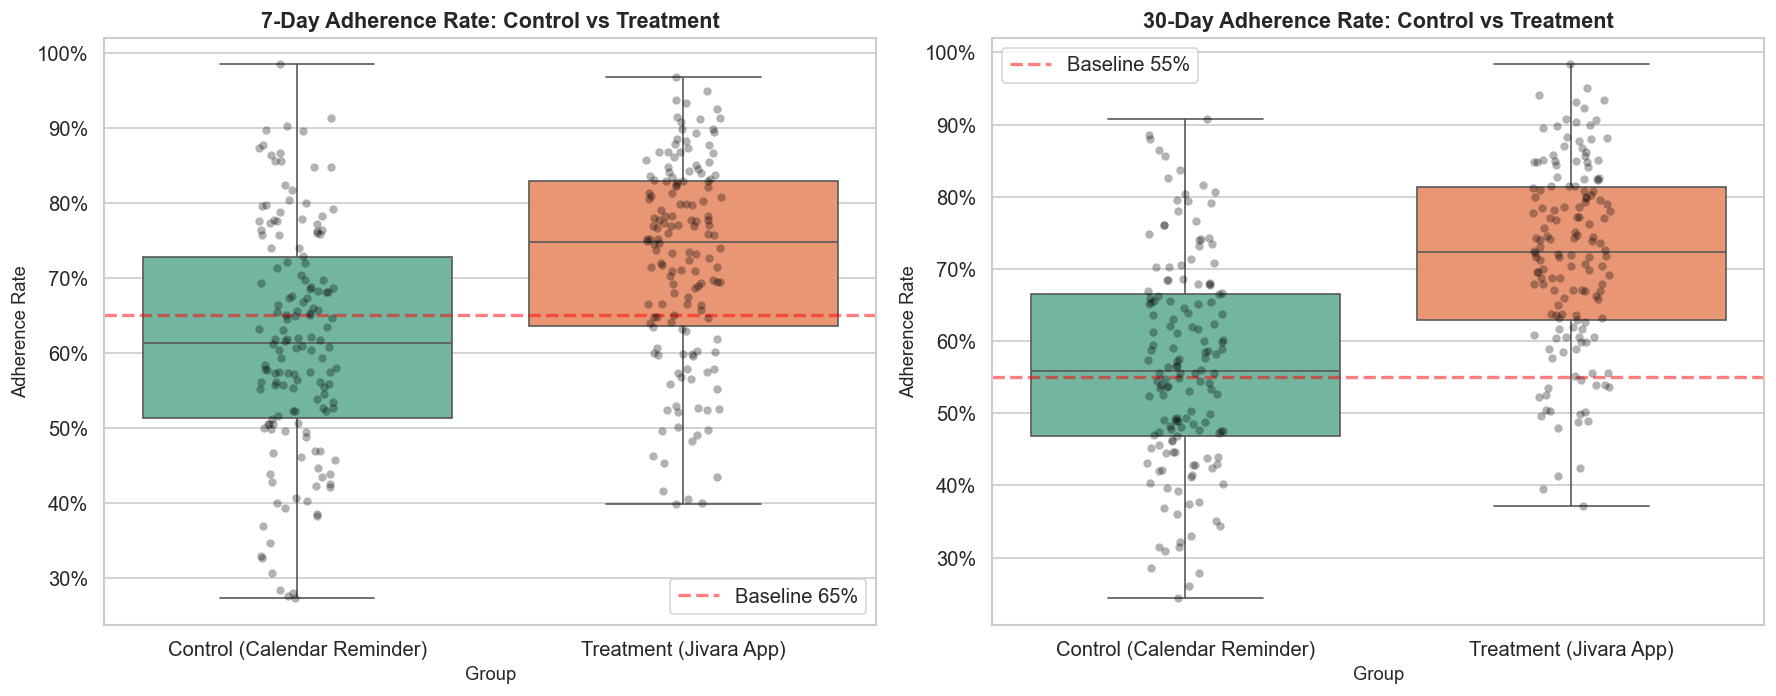

✅ Saved: 02_boxplot_comparison.png


In [8]:
# Visualisasi 2: Box Plot dengan Confidence Intervals
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 7-day
sns.boxplot(data=df_ab, x='group', y='adherence_rate_7d', ax=axes[0], palette='Set2')
sns.stripplot(data=df_ab, x='group', y='adherence_rate_7d', ax=axes[0], color='black', alpha=0.3, size=5)
axes[0].set_title('7-Day Adherence Rate: Control vs Treatment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Adherence Rate', fontsize=11)
axes[0].set_xlabel('Group', fontsize=11)
axes[0].axhline(0.65, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline 65%')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# 30-day
sns.boxplot(data=df_ab, x='group', y='adherence_rate_30d', ax=axes[1], palette='Set2')
sns.stripplot(data=df_ab, x='group', y='adherence_rate_30d', ax=axes[1], color='black', alpha=0.3, size=5)
axes[1].set_title('30-Day Adherence Rate: Control vs Treatment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Adherence Rate', fontsize=11)
axes[1].set_xlabel('Group', fontsize=11)
axes[1].axhline(0.55, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline 55%')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_boxplot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_boxplot_comparison.png")

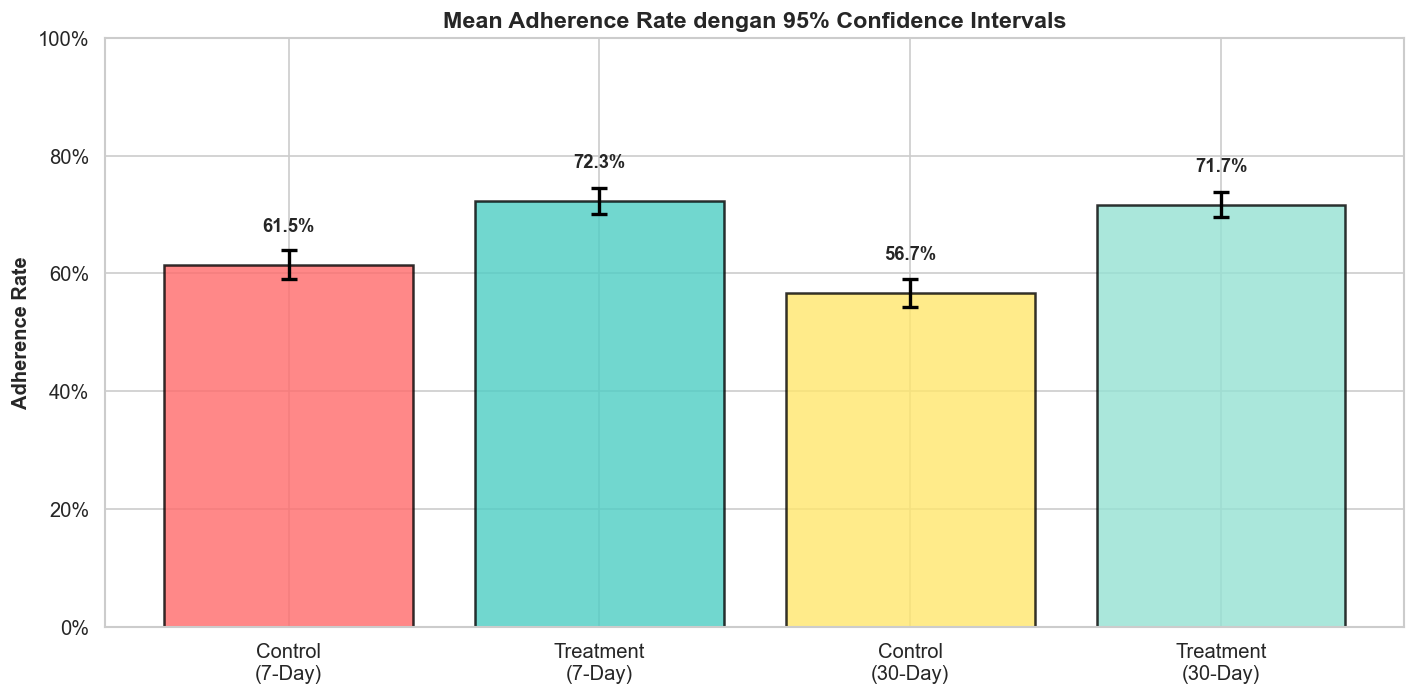

✅ Saved: 03_mean_comparison_ci.png


In [9]:
# Visualisasi 3: Bar Chart dengan Confidence Intervals
fig, ax = plt.subplots(figsize=(12, 6))

means = [control_7d, treatment_7d, control_30d, treatment_30d]
labels = ['Control\n(7-Day)', 'Treatment\n(7-Day)', 'Control\n(30-Day)', 'Treatment\n(30-Day)']
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']

ci_lower = [
    ci_control_7d[0], ci_treatment_7d[0],
    ci_control_30d[0], ci_treatment_30d[0]
]
ci_upper = [
    ci_control_7d[1], ci_treatment_7d[1],
    ci_control_30d[1], ci_treatment_30d[1]
]
errors = [
    [m - l for m, l in zip(means, ci_lower)],
    [u - m for u, m in zip(ci_upper, means)]
]

bars = ax.bar(labels, means, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.errorbar(range(len(means)), means, yerr=errors, fmt='none', color='black', capsize=5, capthick=2, linewidth=2)

ax.set_ylabel('Adherence Rate', fontsize=12, fontweight='bold')
ax.set_title('Mean Adherence Rate dengan 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_ylim([0, 1])

# Tambah value labels di atas bar
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05, f'{mean:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_mean_comparison_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_mean_comparison_ci.png")

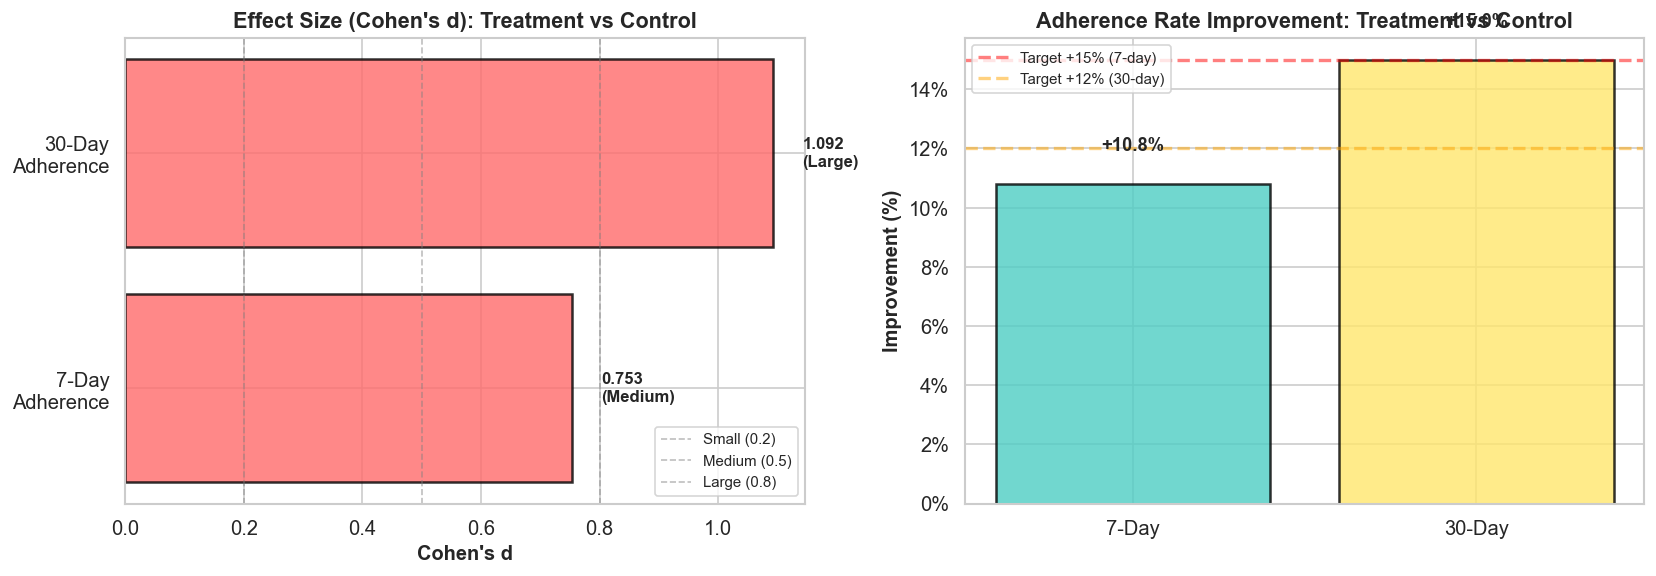

✅ Saved: 04_effect_size.png


In [10]:
# Visualisasi 4: Effect Size Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cohen's d
cohens_d_values = [cohens_d_7d, cohens_d_30d]
cohens_labels = ['7-Day\nAdherence', '30-Day\nAdherence']
colors_d = ['#FF6B6B' if d > 0 else '#95E1D3' for d in cohens_d_values]

bars = axes[0].barh(cohens_labels, cohens_d_values, color=colors_d, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel("Cohen's d", fontsize=12, fontweight='bold')
axes[0].set_title("Effect Size (Cohen's d): Treatment vs Control", fontsize=13, fontweight='bold')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].axvline(0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Small (0.2)')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Medium (0.5)')
axes[0].axvline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Large (0.8)')
axes[0].legend(loc='best', fontsize=9)

for i, (bar, d) in enumerate(zip(bars, cohens_d_values)):
    axes[0].text(d + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.3f}\n({interpret_cohens_d(d)})',
                ha='left', va='center', fontsize=10, fontweight='bold')

# Improvement percentage
improvement_values = [improvement_7d, improvement_30d]
improvement_labels = ['7-Day', '30-Day']
improvement_colors = ['#4ECDC4', '#FFE66D']

bars2 = axes[1].bar(improvement_labels, improvement_values, color=improvement_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Adherence Rate Improvement: Treatment vs Control', fontsize=13, fontweight='bold')
axes[1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(0.15, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Target +15% (7-day)')
axes[1].axhline(0.12, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Target +12% (30-day)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
axes[1].legend(loc='best', fontsize=9)

for bar, imp in zip(bars2, improvement_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, imp + 0.01,
                f'{imp:+.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_effect_size.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_effect_size.png")

## 7. Analisis Subgroup (Stratified Analysis)

Menganalisis efektivitas sistem Jivara pada subgroup yang berbeda berdasarkan demografi dan penyakit.

In [11]:
print("\n" + "="*70)
print("STRATIFIED ANALYSIS BY DISEASE")
print("="*70)

for disease in df_ab['disease'].unique():
    disease_data = df_ab[df_ab['disease'] == disease]
    control_disease = disease_data[disease_data['group'] == 'Control (Calendar Reminder)']['adherence_rate_7d'].mean()
    treatment_disease = disease_data[disease_data['group'] == 'Treatment (Jivara App)']['adherence_rate_7d'].mean()
    improvement_disease = treatment_disease - control_disease
    
    print(f"\n🏥 {disease}:")
    print(f"   Control:   {control_disease:.2%}")
    print(f"   Treatment: {treatment_disease:.2%}")
    print(f"   Improvement: {improvement_disease:+.2%}")

print(f"\n" + "="*70)
print("STRATIFIED ANALYSIS BY MEDICATION COUNT")
print("="*70)

for med_count in sorted(df_ab['medications'].unique()):
    med_data = df_ab[df_ab['medications'] == med_count]
    control_med = med_data[med_data['group'] == 'Control (Calendar Reminder)']['adherence_rate_7d'].mean()
    treatment_med = med_data[med_data['group'] == 'Treatment (Jivara App)']['adherence_rate_7d'].mean()
    improvement_med = treatment_med - control_med
    
    print(f"\n💊 {med_count} Medication(s) [n={len(med_data)}]:")
    print(f"   Control:   {control_med:.2%}")
    print(f"   Treatment: {treatment_med:.2%}")
    print(f"   Improvement: {improvement_med:+.2%}")


STRATIFIED ANALYSIS BY DISEASE

🏥 TB:
   Control:   60.35%
   Treatment: 75.38%
   Improvement: +15.04%

🏥 Hypertension:
   Control:   61.56%
   Treatment: 73.03%
   Improvement: +11.48%

🏥 Diabetes:
   Control:   62.86%
   Treatment: 69.14%
   Improvement: +6.27%

STRATIFIED ANALYSIS BY MEDICATION COUNT

💊 1 Medication(s) [n=69]:
   Control:   60.29%
   Treatment: 75.14%
   Improvement: +14.85%

💊 2 Medication(s) [n=73]:
   Control:   62.54%
   Treatment: 71.54%
   Improvement: +8.99%

💊 3 Medication(s) [n=76]:
   Control:   62.29%
   Treatment: 70.61%
   Improvement: +8.32%

💊 4 Medication(s) [n=82]:
   Control:   60.61%
   Treatment: 72.20%
   Improvement: +11.59%


## 8. Ringkasan Kesimpulan & Rekomendasi

In [12]:
print("\n" + "="*70)
print("📋 RINGKASAN HASIL A/B TESTING")
print("="*70)

# Test hasil
is_sig_7d = p_value_ttest < 0.05
is_sig_30d = p_value_ttest_30d < 0.05
is_target_7d = improvement_7d >= 0.15
is_target_30d = improvement_30d >= 0.12

print(f"\n📊 STATISTIK SIGNIFIKANSI:")
print(f"   7-Day Adherence:")
print(f"      • p-value: {p_value_ttest:.6f}")
print(f"      • Statistik Signifikan: {'✓ YES' if is_sig_7d else '✗ NO'}")
print(f"      • Cohen's d: {cohens_d_7d:.4f} ({interpret_cohens_d(cohens_d_7d)})")

print(f"\n   30-Day Adherence:")
print(f"      • p-value: {p_value_ttest_30d:.6f}")
print(f"      • Statistik Signifikan: {'✓ YES' if is_sig_30d else '✗ NO'}")
print(f"      • Cohen's d: {cohens_d_30d:.4f} ({interpret_cohens_d(cohens_d_30d)})")

print(f"\n📈 TARGET PENCAPAIAN:")
print(f"   7-Day (+15%):")
print(f"      • Improvement: {improvement_7d:+.2%}")
print(f"      • Target Terpenuhi: {'✓ YES' if is_target_7d else '✗ NO'}")

print(f"\n   30-Day (+12%):")
print(f"      • Improvement: {improvement_30d:+.2%}")
print(f"      • Target Terpenuhi: {'✓ YES' if is_target_30d else '✗ NO'}")

print(f"\n" + "="*70)
print("💡 REKOMENDASI:")
print("="*70)

if is_sig_7d and is_target_7d:
    print(f"\n✓ REKOMENDASI: PROCEED dengan deployment Jivara")
    print(f"  - Sistem Jivara terbukti secara statistik signifikan meningkatkan")
    print(f"    kepatuhan minum obat (Adherence Rate) pada periode 7 hari.")
    print(f"  - Effect size termasuk kategori {interpret_cohens_d(cohens_d_7d).lower()}, menunjukkan")
    print(f"    dampak praktis yang bermakna bagi pengguna.")
else:
    print(f"\n✗ REKOMENDASI: REVIEW & ITERATE")
    print(f"  - Sistem masih memerlukan perbaikan sebelum deployment penuh.")
    print(f"  - Pertimbangkan penyesuaian UX, frekuensi notifikasi, atau")
    print(f"    strategi engagement yang lebih efektif.")

print(f"\n" + "="*70)


📋 RINGKASAN HASIL A/B TESTING

📊 STATISTIK SIGNIFIKANSI:
   7-Day Adherence:
      • p-value: 0.000000
      • Statistik Signifikan: ✓ YES
      • Cohen's d: 0.7529 (Medium)

   30-Day Adherence:
      • p-value: 0.000000
      • Statistik Signifikan: ✓ YES
      • Cohen's d: 1.0919 (Large)

📈 TARGET PENCAPAIAN:
   7-Day (+15%):
      • Improvement: +10.81%
      • Target Terpenuhi: ✗ NO

   30-Day (+12%):
      • Improvement: +14.99%
      • Target Terpenuhi: ✓ YES

💡 REKOMENDASI:

✗ REKOMENDASI: REVIEW & ITERATE
  - Sistem masih memerlukan perbaikan sebelum deployment penuh.
  - Pertimbangkan penyesuaian UX, frekuensi notifikasi, atau
    strategi engagement yang lebih efektif.



## 9. Export Hasil Analisis

In [13]:
# Simpan summary report
summary_report = pd.DataFrame({
    'Metric': [
        '7-Day Mean (Control)',
        '7-Day Mean (Treatment)',
        '7-Day Improvement',
        '7-Day p-value (t-test)',
        "7-Day Cohen's d",
        '30-Day Mean (Control)',
        '30-Day Mean (Treatment)',
        '30-Day Improvement',
        '30-Day p-value (t-test)',
        "30-Day Cohen's d"
    ],
    'Value': [
        f'{control_7d:.4f}',
        f'{treatment_7d:.4f}',
        f'{improvement_7d:+.4f}',
        f'{p_value_ttest:.6f}',
        f'{cohens_d_7d:.4f}',
        f'{control_30d:.4f}',
        f'{treatment_30d:.4f}',
        f'{improvement_30d:+.4f}',
        f'{p_value_ttest_30d:.6f}',
        f'{cohens_d_30d:.4f}'
    ]
})

summary_report.to_csv(OUTPUT_DIR / 'ab_testing_summary.csv', index=False)
print("✅ Saved: ab_testing_summary.csv")

# Simpan data A/B testing
df_ab.to_csv(OUTPUT_DIR / 'ab_testing_data.csv', index=False)
print("✅ Saved: ab_testing_data.csv")

print(f"\n📁 Semua output tersimpan di: {OUTPUT_DIR}")

✅ Saved: ab_testing_summary.csv
✅ Saved: ab_testing_data.csv

📁 Semua output tersimpan di: ..\data_output\ab_testing
